Part 1

In [2]:
#Importing the relevant modules
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
#Import the simulation data 
hdul=fits.open("data/nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits")
hdul.info()
#extract data
data=hdul[1].data
print(data.columns)
#Extract the columns from the .fits file that I need 
x=data['x']
y=data['y']
z=data['z']
R_gal=np.sqrt(x**2+y**2)
A_0=data['A_O']

Filename: data/nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (678,)   uint8   
  1  /Users/buder/Simulations/preparing_NIHAO/NIHAO_prepared/NIHAO_g8.26e    1 BinTableHDU     21   511520R x 4C   [E, E, E, D]   
3914451405.py: ColDefs(
    name = 'x'; format = 'E'
    name = 'y'; format = 'E'
    name = 'z'; format = 'E'
    name = 'A_O'; format = 'D'
)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


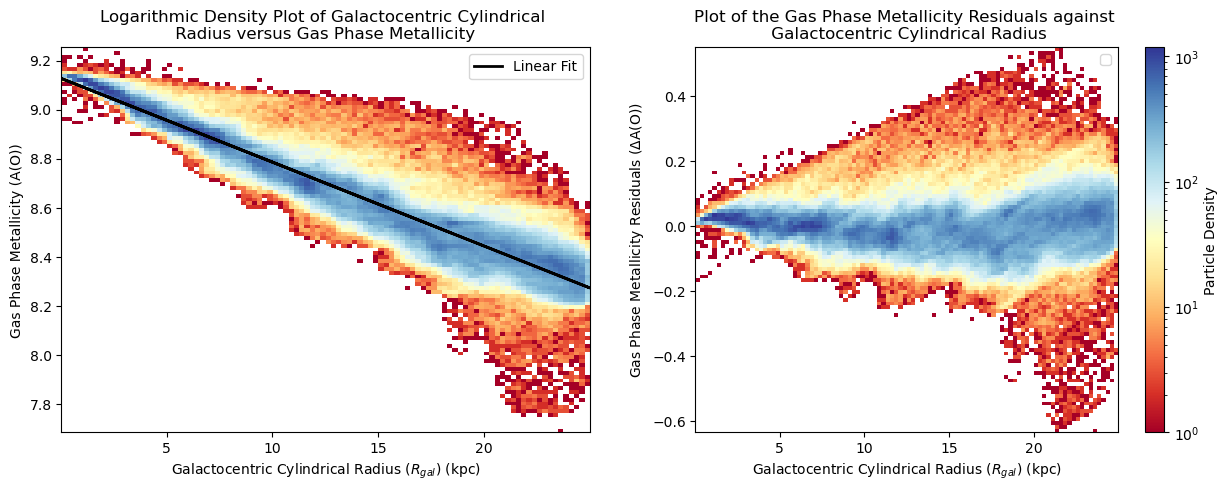

<Figure size 640x480 with 0 Axes>

In [7]:
from matplotlib.colors import LogNorm
plt.style.use('default')
fig, (ax1, ax2)= plt.subplots(1,2, figsize=(15, 5))
#Do the linear fit
linear_fit = np.polyfit(R_gal, A_0, 1)  # 1 for linear
m, b = linear_fit
linear_fit_plot=m*R_gal+b
im=ax1.hist2d(R_gal, A_0, bins=100, norm=LogNorm(), cmap='RdYlBu')
ax1.plot(R_gal, linear_fit_plot, color='black', linewidth=2, label='Linear Fit')
ax1.set_xlabel('Galactocentric Cylindrical Radius ($R_{gal}$) (kpc)')
ax1.set_ylabel('Gas Phase Metallicity (A(O))')
ax1.set_title(f'Logarithmic Density Plot of Galactocentric Cylindrical \n Radius versus Gas Phase Metallicity ')
ax1.legend()
# Do the second plot of the residuals of the fit against the galactocentric cylindrical radius
#residuals=data-model
residuals=A_0-linear_fit_plot
im=ax2.hist2d(R_gal, residuals, bins=100, norm=LogNorm(), cmap='RdYlBu')
ax2.set_xlabel('Galactocentric Cylindrical Radius ($R_{gal}$) (kpc)')
ax2.set_ylabel('Gas Phase Metallicity Residuals ($\Delta$A(O))')
fig.colorbar(im[3], label='Particle Density', ax=ax2)
ax2.set_title(f'Plot of the Gas Phase Metallicity Residuals against \n Galactocentric Cylindrical Radius')
ax2.legend()
plt.show()
plt.savefig("figures/Q2Part1LogDenisty_ResidualsTwoPanelPlot.png", dpi=300, bbox_inches="tight")

In [31]:
print(len(R_gal))

1525092337.py: 511520


Part 2

<small> I used np.polyfit to fit a line (y=mx+b) to the data with cov=True hyperparameter added to ensure the uncertainties were also returned for the intercept and slope of the fit. </small>

In [16]:
#Using np.polyfit with cov=True so we get uncertainties
linear_fit, cov = np.polyfit(R_gal, A_0, 1, cov=True)  # 1 for linear
m, b = linear_fit
#Fitted A_O values are 
fitted_A_O=m*R_gal+b
#Uncertainties are the square root of the diagonal elements in the covariance matrix
m_unc= np.sqrt(cov[0,0])
b_unc= np.sqrt(cov[1,1])
#Report the intercept and slope with uncertainties
print(f'The slope (m) of the fit is, {m:.2e} \u00B1 {m_unc:.2e}') 
print(f'The intercept (b) of the fit is, {b:.2e} \u00B1 {b_unc:.2e}') 

1392138259.py: The slope (m) of the fit is, -3.42e-02 ± 1.48e-05


1392138259.py: The intercept (b) of the fit is, 9.13e+00 ± 2.32e-04


Part 3

<small> As seen in the part 1 plot, the linear model fits well for the data at less than 10 kpc in $R_{gal}$ but then does not do as well in fitting the data above this point as it begins to look more exponential with a larger spread of gas phase metallicities at higher galactocentric cylindrical radii. Below I used the python statsmodel to produce a summary of some key statistical results and measures of goodness of fit to assess the overall performance of the linear fit. As can be seen, compared to the scale of the uncertainty of the slope and intercept from the linear fit, an RMSE of 0.07 is quite a bit larger than this, which might be a result of larger residuals at R_gal greater than 10kpc which the linear model is unable to fit as well. The R-squared value of 0.913 in this case is misleading as the large number of points and the spread of the data makes it to seem like the linear model is explaining the variance well even though the underlying relationship is more non-linear. </small>

In [5]:
#Using this module to get some key statistical results
import statsmodels.api as sm
x_with_intercept = sm.add_constant(R_gal)  # Adding the intercept term
linear_model = sm.OLS(A_0, x_with_intercept).fit()
# Print linear model summary with the required statistical information
print(linear_model.summary())
#Also calculating the RMSE from the returned residuals gives
RMSE=np.sqrt(np.mean(linear_model.resid**2))
print(f'The Root Mean Square is {RMSE:.2f}')

1430977943.py:                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                 5.337e+06
Date:                Mon, 31 Aug 2026   Prob (F-statistic):               0.00
Time:                        21:17:59   Log-Likelihood:             6.1547e+05
No. Observations:              511520   AIC:                        -1.231e+06
Df Residuals:                  511518   BIC:                        -1.231e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.1278      0.000   3.

Part 4

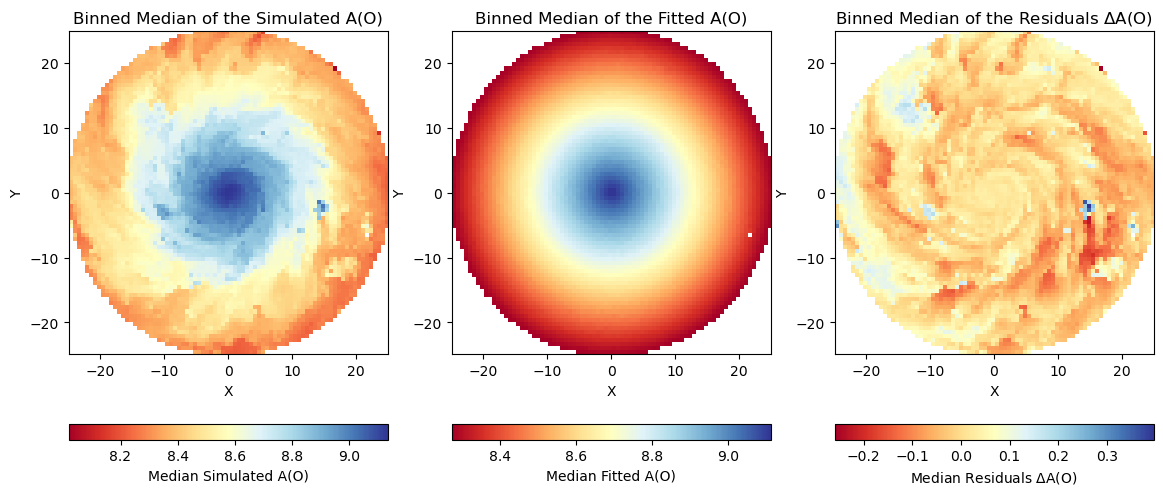

In [32]:
#Importing the necessary module for 2D histograms
from scipy.stats import binned_statistic_2d
#Setting up the three-panel plot
fig, (ax1,ax2,ax3)= plt.subplots(1,3,figsize=(14,6))
#For part a, doing a 2D histogram of the median simulated A(0) for the x vs. y plane
bin_stat_mean, xedges, yedges, binnumber = binned_statistic_2d(x, y, A_0, statistic='median', bins=80)
im1 = ax1.imshow(bin_stat_mean.T, origin='lower', aspect='auto',
                   extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                   cmap='RdYlBu')
ax1.set_title("Binned Median of the Simulated A(O)")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
plt.colorbar(im1, ax=ax1, label="Median Simulated A(O)", orientation='horizontal')
#For part b, doing a 2D histogram of the median fitted A(O) for the x vs. y plane
bin_stat_mean2, xedges2, yedges2, binnumber2 = binned_statistic_2d(x, y, fitted_A_O, statistic='median', bins=80)
im2 = ax2.imshow(bin_stat_mean2.T, origin='lower', aspect='auto',
                   extent=[xedges2[0], xedges2[-1], yedges2[0], yedges2[-1]],
                   cmap='RdYlBu')
ax2.set_title("Binned Median of the Fitted A(O)")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
plt.colorbar(im2, ax=ax2, label="Median Fitted A(O)", orientation='horizontal')
#For part c, doing a 2D histogram of the median residuals \Delta A(0) for the x vs. y plane
bin_stat_mean3, xedges3, yedges3, binnumber3 = binned_statistic_2d(x, y, residuals, statistic='median', bins=80)
im3 = ax3.imshow(bin_stat_mean3.T, origin='lower', aspect='auto',
                   extent=[xedges3[0], xedges3[-1], yedges3[0], yedges3[-1]],
                   cmap='RdYlBu')
ax3.set_title("Binned Median of the Residuals $\Delta$A(O)")
ax3.set_xlabel("X")
ax3.set_ylabel("Y")
plt.colorbar(im3, ax=ax3, label="Median Residuals $\Delta$A(O)", orientation='horizontal')
#plt.savefig("figures/Q3Part4_2DHistograms.png", dpi=300, bbox_inches="tight")

Part 5

<small> When you use too small of a number of bins such as 30, some trends or important details get blended together so that they are not as obvious especially when trying to identify regions of lower and higher density. Whereas too many bins is more computationally expensive and you also start to get fewer and fewer counts per bin and so some of the significance is lost and the resulting histogram is more noisy and sparse as a result. For this data in particular, at 200 bins you started to get a few white sections in the 2D histograms as there were not enough counts per bin. </small>

Part 6

<small> Looking at the 2D histogram of the median residuals of the gas phase metallicity in Part 4, there appears to be more negative residuals (oranger/red colours) along what appear to be the spiral arms in the simulated Milky Way-like Spiral Galaxy, suggesting that in these areas, the model prediction is higher than the data. This makes physical sense, as these orange/red colours infer an under-density or lower gas phase metallcity than is expected by the model which would be the case in spiral arms which are active sites of star formation so fresh, low-metallcity gas is inflowing into these regions. The positive residuals (bluer) on the outskirts suggests that the linear model prediction was lower than the simulated data or that there is an overdensity in these regions. This makes sense as at the larger values of R_gal, near the outskirt areas that are blue, there was more of a spread in metallicty due to the non-linear data, thus resulting in the lienar model having smaller values of metallicity. In terms of a physical interpretation, this may provide evidence for radial migration and outflows as mentioned in the question where more metal rich gas and stars can be transported outwards and the gas is thereforw more metal rich and less diluted by fresh inflows than in the spiral arms where there is more active star formation.   </small>